In [105]:
df["High_Performance"] = (
    df["Percentage of patients who spend at least 90% of their time on a stroke unit "] > 0.85
).astype(int)
df.head()

,Unnamed: 0,Year,Quarter,SHA,Org Code,Org Name,Patients who spend at least 90% of their time on a stroke unit,Number of people who were admitted to hospital following a stroke,Percentage of patients who spend at least 90% of their time on a stroke unit,High_Performance
0,NaN,2012-13,1.0,NaN,NaN,England,15816.0,18754.0,0.843340,0
2,NaN,2012-13,1.0,Q31,5HG,"ASHTON, LEIGH AND WIGAN PCT",120.0,154.0,0.779221,0
3,NaN,2012-13,1.0,Q36,5C2,BARKING AND DAGENHAM PCT,44.0,47.0,0.936170,1
4,NaN,2012-13,1.0,Q36,5A9,BARNET PCT,118.0,123.0,0.959350,1
5,NaN,2012-13,1.0,Q32,5JE,BARNSLEY PCT,102.0,114.0,0.894737,1


In [107]:
df["High_Performance"].value_counts()

High_Performance
1    335
0    273
Name: count, dtype: int64

In [109]:
df.columns = df.columns.str.strip()
df.columns.tolist()
X = df[
    [
        "Number of people who were admitted to hospital following a stroke",
        "Patients who spend at least 90% of their time on a stroke unit"
    ]
]

y = df["High_Performance"]
X.head()
y.head()

0    0
2    0
3    1
4    1
5    1
Name: High_Performance, dtype: int64

In [111]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [113]:
X_train.shape, X_test.shape

((486, 2), (122, 2))

In [115]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create model
log_model = LogisticRegression()

# Train model
log_model.fit(X_train, y_train)

# Predict
y_pred_log = log_model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.9918032786885246

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.98      0.99        55
           1       0.99      1.00      0.99        67

    accuracy                           0.99       122
   macro avg       0.99      0.99      0.99       122
weighted avg       0.99      0.99      0.99       122



In [117]:
# Random Forest:

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9098360655737705

Classification Report:

              precision    recall  f1-score   support

           0       0.94      0.85      0.90        55
           1       0.89      0.96      0.92        67

    accuracy                           0.91       122
   macro avg       0.91      0.90      0.91       122
weighted avg       0.91      0.91      0.91       122



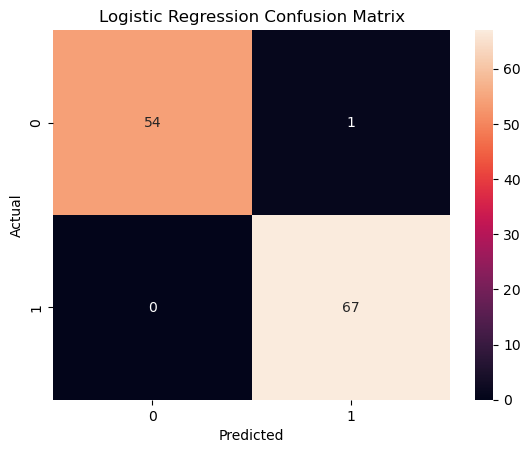

In [119]:
# Confusion Matrix:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

sns.heatmap(cm, annot = True, fmt = "d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [121]:
# for Logistic Regression (Coefficents):

import pandas as pd

importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})
importance

,Feature,Coefficient
0,Number of people who were admitted to hospital...,-2.319910
1,Patients who spend at least 90% of their time ...,2.739311


In [19]:
#now loading all 4 quarters:

def load_clean(file_path):
    df = pd.read_excel(file_path, skiprows = 8)
    df.columns = df.columns.str.strip()

    # Look for possible organisation column names
    possible_cols = [col for col in df.columns 
                     if "Org" in col or "Organisation" in col]

    if len(possible_cols) == 0:
        print("Columns found:", df.columns)
        raise ValueError ("No organisation column found!")

    org_col = possible_cols [0]

    
    df = df.dropna(subset = [org_col])
    df = df[df[org_col] != "England"]

    return df

In [21]:
# trying to find the org name inside but then it can't be on 
# the 8th column for every file or year can it? so ran this 
# to first find out what the names where

df_test = pd.read_excel("../../data/raw/Stroke-Web-file-Q1-2012-13-revised-15.05.2013.xls", skiprows=8)
print(df_test.columns)

Index(['Unnamed: 0', 'Revised:', '9th May 2013', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8'],
      dtype='object')


In [23]:
# for Q1, find the column of Org:
df_preview = pd.read_excel(
    "../../data/raw/Stroke-Web-file-Q1-2012-13-revised-15.05.2013.xls",
    header=None
)

df_preview.head(20)

,0,1,2,3,4,5,6,7,8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Title:,Number of people who were admitted to hospital...,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Summary:,IPMR Stroke is the collection of data to monit...,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Period:,April to June 2012,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Source:,Department of Health: Unify2 data collection -...,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,Basis:,Commissioner,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,Published:,15th August 2012,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,Revised:,9th May 2013,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Status:,Revised,NaN,NaN,NaN,NaN,NaN,NaN


In [25]:
df = pd.read_excel(
    "../../data/raw/Stroke-Web-file-Q1-2012-13-revised-15.05.2013.xls",
    header=13
)

df.columns

Index(['Unnamed: 0', 'Year', 'Quarter', 'SHA', 'Org Code', 'Org Name',
       'Patients who spend at least 90% of their time on a stroke unit ',
       'Number of people who were admitted to hospital following a stroke',
       'Percentage of patients who spend at least 90% of their time on a stroke unit '],
      dtype='object')

In [27]:
# for Q2. trying to find the org column first:
df_preview = pd.read_excel(
    "../../data/raw/Stroke-Web-file-Q2-2012-13-revised-15.05.2013.xls",
    header=None
)

df_preview.head(20)

,0,1,2,3,4,5,6,7,8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Title:,Number of people who were admitted to hospital...,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Summary:,IPMR Stroke is the collection of data to monit...,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Period:,July to September 2012,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Source:,Department of Health: Unify2 data collection -...,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,Basis:,Commissioner,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,Published:,14th November 2012,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,Revised:,15th May 2013,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Status:,Revised,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# for Q3. trying to find the org column first:
df_preview = pd.read_excel(
    "../../data/raw/Stroke-Web-file-Q3-2012-13-revised-15.05.2013.xls",
    header=None
)

df_preview.head(20)

,0,1,2,3,4,5,6,7,8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Title:,Number of people who were admitted to hospital...,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Summary:,IPMR Stroke is the collection of data to monit...,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Period:,October to December 2012,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Source:,Department of Health: Unify2 data collection -...,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,Basis:,Commissioner,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,Published:,13th February 2013,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,Revised:,15th May 2013,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Status:,Revised,NaN,NaN,NaN,NaN,NaN,NaN


In [31]:
# for Q4. trying to find the org column first:
df_preview = pd.read_excel(
    "../../data/raw/Stroke-Web-file-Q4-2012-13.xls",
    header=None
)

df_preview.head(20)

,0,1,2,3,4,5,6,7,8
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Title:,Number of people who were admitted to hospital...,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,Summary:,IPMR Stroke is the collection of data to monit...,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,Period:,January to March 2013,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,Source:,Department of Health: Unify2 data collection -...,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,Basis:,Commissioner,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,Published:,15th May 2013,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,Revised:,-,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,Status:,Published,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
#Data Loading function:

def load_clean(file_path, header_row):
    df = pd.read_excel(file_path, header=header_row)
    df.columns = df.columns.str.strip()

    org_col = [col for col in df.columns 
               if "Org" in col or "Organisation" in col][0]

    df = df.dropna(subset=[org_col])
    df = df[df[org_col] != "England"]

    return df

In [35]:
#Load NHS datasets:

df_q1 = load_clean("../../data/raw/Stroke-Web-file-Q1-2012-13-revised-15.05.2013.xls", 13)
df_q2 = load_clean("../../data/raw/Stroke-Web-file-Q2-2012-13-revised-15.05.2013.xls", 13)
df_q3 = load_clean("../../data/raw/Stroke-Web-file-Q3-2012-13-revised-15.05.2013.xls", 13)
df_q4 = load_clean("../../data/raw/Stroke-Web-file-Q4-2012-13.xls", 13)

In [37]:
#Combine datasets:

df_all = pd.concat([df_q1, df_q2, df_q3, df_q4], ignore_index=True)

df_all.shape

(604, 9)

In [39]:
df_all["Org Name"].nunique()

151

In [41]:
# Create target variable:

df_all["High_Performance"] = (
    df_all["Percentage of patients who spend at least 90% of their time on a stroke unit"] > 0.85
).astype(int)

df_all["High_Performance"].value_counts()

High_Performance
1    333
0    271
Name: count, dtype: int64

In [43]:
# train and test split:

from sklearn.model_selection import train_test_split

# Define X and y
X = df_all[["Number of people who were admitted to hospital following a stroke"]]
y = df_all["High_Performance"]

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((483, 1), (121, 1))

In [47]:
#🧠 Look at the Classification Report
#For class 0 (Low Performance):
#Precision: 0.44
#Recall: 0.20 ❌ (very low)
#For class 1 (High Performance):
#Precision: 0.55
#Recall: 0.79

#this means:

#The model predicts most organisations as high-performing
#It struggles to detect low-performing ones

#Why?
#Because the relationship is probably not linear.

#Now we run Random Forest and if it outperforms better than it means the relationship 
#between admission volume and performance classification

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state = 42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassificatio Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.5289256198347108

Classificatio Report:

              precision    recall  f1-score   support

           0       0.46      0.35      0.40        54
           1       0.56      0.67      0.61        67

    accuracy                           0.53       121
   macro avg       0.51      0.51      0.51       121
weighted avg       0.52      0.53      0.52       121



In [49]:
#High_Performance = (Percentage > 0.85)

#But you did NOT include the percentage itself in modelling (correctly).

#So you are asking:

#Can admission volume alone predict whether percentage > 85%?

#And the answer is:

#Not really.

#Which makes logical sense.

#so we check what we have available, going for columns and rows:

df_all.columns

Index(['Unnamed: 0', 'Year', 'Quarter', 'SHA', 'Org Code', 'Org Name',
       'Patients who spend at least 90% of their time on a stroke unit',
       'Number of people who were admitted to hospital following a stroke',
       'Percentage of patients who spend at least 90% of their time on a stroke unit',
       'High_Performance'],
      dtype='object')

In [51]:
#Feature preparation:

#1.ENCODE QUARTER AND SHA:

df_model = df_all.copy()

# Select features
X = df_model[[
    "Number of people who were admitted to hospital following a stroke",
    "Quarter",
    "SHA"
]]

y = df_model["High_Performance"]

# One-hot encode categorical variables
X = pd.get_dummies(X, columns=["Quarter", "SHA"], drop_first=True)

X.shape

(604, 13)

In [53]:
# now we have moved from 1 feature to 13 yay.
# the model can learn:
# regional differences, time variation, volume effects, interaction - type behaviour

#rerun train-test split:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape

((483, 13), (121, 13))

In [55]:
#running the logistic regression model with 13 features dataset (with quater + SHA encoded)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.6528925619834711

Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.67      0.63        54
           1       0.70      0.64      0.67        67

    accuracy                           0.65       121
   macro avg       0.65      0.65      0.65       121
weighted avg       0.66      0.65      0.65       121



In [57]:
#now trying with random forest:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.6446280991735537

Classification Report:

              precision    recall  f1-score   support

           0       0.61      0.56      0.58        54
           1       0.67      0.72      0.69        67

    accuracy                           0.64       121
   macro avg       0.64      0.64      0.64       121
weighted avg       0.64      0.64      0.64       121



In [59]:
# ok now I could structure ita s admission volume only 53%
# regional and temproal features 65%
#random forest = logistic regression

import pandas as pd

importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feature_importance_df

,Feature,Importance
0,Number of people who were admitted to hospital...,0.594691
9,SHA_Q36,0.116599
12,SHA_Q39,0.054288
4,SHA_Q31,0.034453
3,Quarter_4.0,0.032480
1,Quarter_2.0,0.030583
2,Quarter_3.0,0.029052
5,SHA_Q32,0.021473
7,SHA_Q34,0.017895
11,SHA_Q38,0.017775


In [69]:
# now cross-validate logistic regression:

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter = 1000)

cv_scores_log = cross_val_score(
    log_model,
    X,
    y,
    cv = 5,
    scoring = "accuracy"
)
print("Logistic Regression CV Scores:", cv_scores_log)
print("Mean Accuracy:", cv_scores_log.mean())

Logistic Regression CV Scores: [0.69421488 0.62809917 0.45454545 0.56198347 0.61666667]
Mean Accuracy: 0.5911019283746557


In [71]:
# cross-validate random forest:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

cv_scores_rf = cross_val_score(
    rf_model, 
    X, 
    y, 
    cv=5, 
    scoring="accuracy"
)

print("Random Forest CV Scores:", cv_scores_rf)
print("Mean Accuracy:", cv_scores_rf.mean())

Random Forest CV Scores: [0.69421488 0.66115702 0.46280992 0.54545455 0.53333333]
Mean Accuracy: 0.5793939393939394


In [73]:
# adding AUC score and ROC curve because it gives threshold-independent evaluation
# also it looks strong in dissertation:

# Logistic Regression AUC:

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get predicted probabilities
y_prob_log = log_model.predict_proba(X_test)[:, 1]

# Compute AUC
auc_log = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression AUC:", auc_log)

# ROC curve
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)

plt.figure()
plt.plot(fpr_log, tpr_log)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.show()

NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [75]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Logistic Regression AUC: 0.7421227197346599


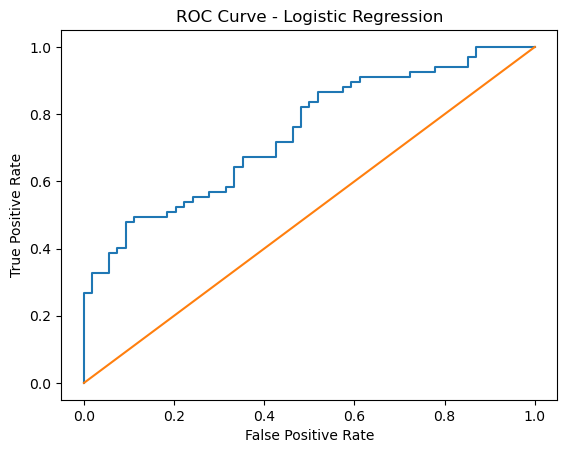

In [77]:
# adding AUC score and ROC curve because it gives threshold-independent evaluation
# also it looks strong in dissertation:

# Logistic Regression AUC:

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Get predicted probabilities
y_prob_log = log_model.predict_proba(X_test)[:, 1]

# Compute AUC
auc_log = roc_auc_score(y_test, y_prob_log)

print("Logistic Regression AUC:", auc_log)

# ROC curve
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)

plt.figure()
plt.plot(fpr_log, tpr_log)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.show()

In [79]:
# AUC code for Random Forest:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)
print("Random Forest AUC:", auc_rf)

NotFittedError: This RandomForestClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [81]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [83]:
# AUC code for Random Forest:
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_prob_rf)
print("Random Forest AUC:", auc_rf)

Random Forest AUC: 0.7143449419568823


In [85]:
# now doing these for all the different files/ years:
import pandas as pd
import glob

# Get all Excel files in folder
files = glob.glob("*.xls")

df_list = []

for file in files:
    temp_df = pd.read_excel(file, header=13)
    df_list.append(temp_df)

# Combine all years
df = pd.concat(df_list, ignore_index=True)

# Drop empty organisation rows
df = df.dropna(subset=["Org Name"])

df.shape

(608, 9)

In [87]:
df = df.dropna(subset=["Org Name"])
df.shape

(608, 9)

In [89]:
df["High_Performance"] = (
    df["Percentage of patients who spend at least 90% of their time on a stroke unit "] > 0.85
).astype(int)

df["High_Performance"].value_counts()

High_Performance
1    335
0    273
Name: count, dtype: int64

In [91]:
# selecting features:
X = df[[
    "Number of people who were admitted to hospital following a stroke",
    "Quarter",
    "SHA"
]]

y = df["High_Performance"]

# One-Hot Encode:

X = pd.get_dummies (X, drop_first = True)
X.shape

(608, 11)

In [93]:
# Train/Test split:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.3, random_state = 42
)
X_train.shape, X_test.shape

((425, 11), (183, 11))

In [95]:
# Logistic Regression:

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

log_model = LogisticRegression(max_iter = 1000)
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.6830601092896175
              precision    recall  f1-score   support

           0       0.59      0.72      0.65        75
           1       0.77      0.66      0.71       108

    accuracy                           0.68       183
   macro avg       0.68      0.69      0.68       183
weighted avg       0.70      0.68      0.69       183



In [97]:
# computing AUC:

y_prob = log_model.predict_proba(X_test)[:,1]
print("AUC:", roc_auc_score(y_test, y_prob))

AUC: 0.7919135802469136


In [99]:
# now we go for cross validation:

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np

# Recreate model:
log_model = LogisticRegression(max_iter=1000)

# 5-fold cross_validation:
cv_scores = cross_val_score(log_model, X, y, cv = 5, scoring = 'accuracy')

print("CV Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))
print("Std Dev:", np.std(cv_scores))

CV Scores: [0.63934426 0.63934426 0.59836066 0.70247934 0.72727273]
Mean CV Accuracy: 0.6613602492887143
Std Dev: 0.04684781837815776


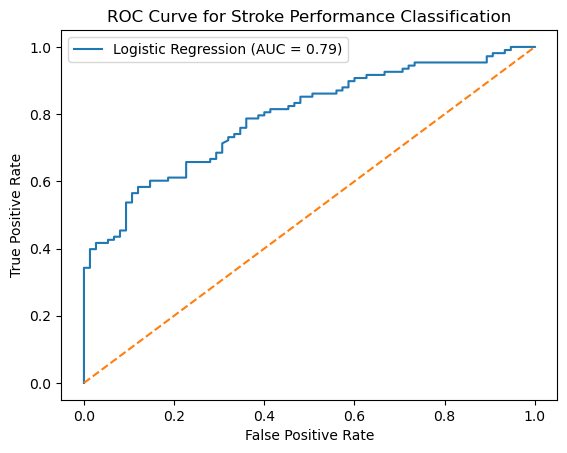

In [103]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="Logistic Regression (AUC = 0.79)")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Stroke Performance Classification")
plt.legend()

plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()